# Recovering the Lorenz Equations with SINDy

This notebook uses the from-scratch **Sparse Identification of Nonlinear Dynamics (SINDy)** implementation to recover the governing equations of the Lorenz system.

The Lorenz system is a useful positive-control experiment because:

- the true equations are known,
- the dynamics are nonlinear,
- the equations are sparse in a quadratic polynomial library,
- the derivatives can be evaluated exactly.

The main questions are:

1. Can SINDy select the correct terms from a larger candidate library?
2. How close are the recovered coefficients to the true coefficients?
3. Why can the derivatives be recovered accurately even though long-run trajectories of a chaotic system may diverge?


## 1. The Lorenz system

The Lorenz equations are

$$
\dot x = \sigma(y-x),
$$

$$
\dot y = x(\rho-z)-y,
$$

$$
\dot z = xy-\beta z.
$$

Using the classical parameters

$$
\sigma=10,
\qquad
\rho=28,
\qquad
\beta=\frac{8}{3},
$$

the system becomes

$$
\dot x=-10x+10y,
$$

$$
\dot y=28x-y-xz,
$$

$$
\dot z=xy-\frac{8}{3}z.
$$

Only seven coefficients are nonzero across the three equations.


## 2. Why SINDy should work here

We use the quadratic candidate library

$$
\Theta(X)
=
[
1,
x,
y,
z,
x^2,
xy,
xz,
y^2,
yz,
z^2
].
$$

SINDy assumes

$$
\dot X\approx \Theta(X)\Xi,
$$

where each column of $\Xi$ contains the coefficients for one state equation.

The true Lorenz system uses only:

- $x$ and $y$ in the $\dot x$ equation,
- $x$, $y$, and $xz$ in the $\dot y$ equation,
- $xy$ and $z$ in the $\dot z$ equation.

Therefore, the true dynamics are sparse in the chosen library.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.library import build_polynomial_library
from src.stlsq import stlsq


## 3. Define the true dynamics

Because the Lorenz equations are known, we can evaluate the derivatives directly rather than estimating them with finite differences.

This gives a clean equation-discovery experiment without derivative-estimation noise.


In [2]:
def lorenz_rhs(
    time,
    state,
    sigma=10.0,
    rho=28.0,
    beta=8.0 / 3.0,
):
    """Evaluate the Lorenz vector field."""
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return np.array([dxdt, dydt, dzdt])


## 4. Simulate a trajectory

We integrate one trajectory from the initial state

$$
(x_0,y_0,z_0)=(1,1,1).
$$

The resulting state matrix has the form

$$
X=
\begin{pmatrix}
x(t_1) & y(t_1) & z(t_1)\\
\vdots & \vdots & \vdots\\
x(t_n) & y(t_n) & z(t_n)
\end{pmatrix}.
$$


In [3]:
dt = 0.01
t_start = 0.0
t_end = 30.0

time_grid = np.arange(t_start, t_end, dt)
initial_state = np.array([1.0, 1.0, 1.0])

solution = solve_ivp(
    fun=lorenz_rhs,
    t_span=(t_start, t_end),
    y0=initial_state,
    t_eval=time_grid,
    rtol=1e-10,
    atol=1e-10,
)

states = solution.y.T

true_derivatives = np.array([
    lorenz_rhs(time, state)
    for time, state in zip(time_grid, states)
])

print("State matrix shape:", states.shape)
print("Derivative matrix shape:", true_derivatives.shape)


State matrix shape: (3000, 3)
Derivative matrix shape: (3000, 3)


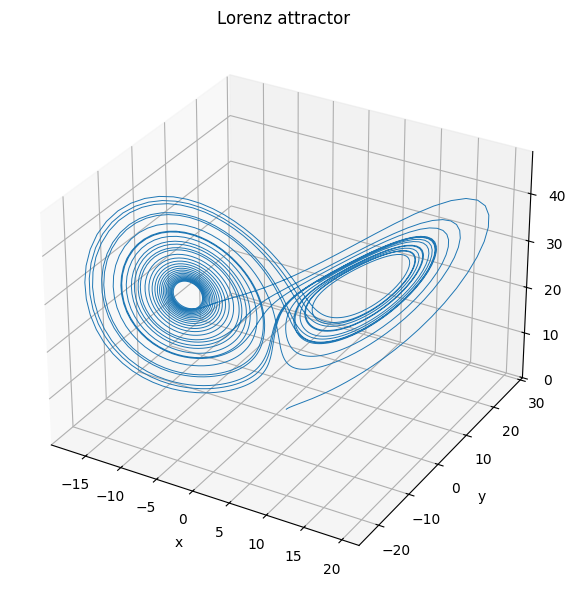

In [4]:
fig = plt.figure(figsize=(8, 6))
axis = fig.add_subplot(111, projection="3d")

axis.plot(
    states[:, 0],
    states[:, 1],
    states[:, 2],
    linewidth=0.7,
)

axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_zlabel("z")
axis.set_title("Lorenz attractor")

plt.tight_layout()
plt.show()


The trajectory remains bounded but is highly sensitive to its initial condition. This sensitivity is the defining chaotic feature of the Lorenz system.


## 5. Build the candidate library

The quadratic library contains ten possible terms:

$$
[
1,
x,
y,
z,
x^2,
xy,
xz,
y^2,
yz,
z^2
].
$$

Across three target equations, this gives $10\times3=30$ possible coefficients. Only seven should remain active.


In [5]:
theta_matrix, feature_names = build_polynomial_library(
    states,
    degree=2,
    include_constant=True,
)

print("Candidate-library shape:", theta_matrix.shape)
print("Feature names:", feature_names)


Candidate-library shape: (3000, 10)
Feature names: ['1', 'x1', 'x2', 'x3', 'x1^2', 'x1x2', 'x1x3', 'x2^2', 'x2x3', 'x3^2']


## 6. Fit SINDy with STLSQ

Sequential Thresholded Least Squares alternates between:

1. least-squares fitting,
2. removal of small coefficients,
3. refitting on the surviving terms.

We use a threshold of $0.05$, which is far below the magnitude of every true nonzero Lorenz coefficient.


In [6]:
coefficients = stlsq(
    theta_matrix,
    true_derivatives,
    threshold=0.05,
    max_iter=20,
)

target_names = ["x_dot", "y_dot", "z_dot"]

coefficient_table = pd.DataFrame(
    coefficients,
    index=feature_names,
    columns=target_names,
)

coefficient_table


,x_dot,y_dot,z_dot
1,0.0,0.0,0.000000
x1,-10.0,28.0,0.000000
x2,10.0,-1.0,0.000000
x3,0.0,0.0,-2.666667
x1^2,0.0,0.0,0.000000
x1x2,0.0,0.0,1.000000
x1x3,0.0,-1.0,0.000000
x2^2,0.0,0.0,0.000000
x2x3,0.0,0.0,0.000000
x3^2,0.0,0.0,0.000000


In [7]:
def format_equation(
    feature_names,
    coefficients,
    target_idx,
    target_name,
    tolerance=1e-10,
):
    """Format one discovered SINDy equation."""
    terms = []

    for feature_name, coefficient in zip(
        feature_names,
        coefficients[:, target_idx],
    ):
        if abs(coefficient) <= tolerance:
            continue

        magnitude = abs(coefficient)

        if not terms:
            sign = "-" if coefficient < 0 else ""
        else:
            sign = "- " if coefficient < 0 else "+ "

        if feature_name == "1":
            term = f"{sign}{magnitude:.6g}"
        else:
            term = f"{sign}{magnitude:.6g}*{feature_name}"

        terms.append(term)

    right_hand_side = " ".join(terms) if terms else "0"
    return f"{target_name} = {right_hand_side}"


for target_idx, target_name in enumerate(target_names):
    print(
        format_equation(
            feature_names,
            coefficients,
            target_idx,
            target_name,
        )
    )


x_dot = -10*x1 + 10*x2
y_dot = 28*x1 - 1*x2 - 1*x1x3
z_dot = -2.66667*x3 + 1*x1x2


The recovered equations should be

$$
\dot x=-10x+10y,
$$

$$
\dot y=28x-y-xz,
$$

$$
\dot z=xy-\frac{8}{3}z.
$$


## 7. Compare recovered and true coefficients

We now construct the exact coefficient matrix in the same library ordering and compare it directly with the SINDy estimate.


In [8]:
expected_coefficients = np.zeros_like(coefficients)

feature_index = {
    name: idx
    for idx, name in enumerate(feature_names)
}

# x_dot = -10*x + 10*y
expected_coefficients[feature_index["x1"], 0] = -10.0
expected_coefficients[feature_index["x2"], 0] = 10.0

# y_dot = 28*x - y - x*z
expected_coefficients[feature_index["x1"], 1] = 28.0
expected_coefficients[feature_index["x2"], 1] = -1.0
expected_coefficients[feature_index["x1x3"], 1] = -1.0

# z_dot = x*y - (8/3)*z
expected_coefficients[feature_index["x1x2"], 2] = 1.0
expected_coefficients[feature_index["x3"], 2] = -(8.0 / 3.0)

comparison_table = pd.DataFrame({
    "term": np.tile(feature_names, 3),
    "equation": np.repeat(target_names, len(feature_names)),
    "true": expected_coefficients.T.reshape(-1),
    "recovered": coefficients.T.reshape(-1),
})

comparison_table["absolute_error"] = np.abs(
    comparison_table["recovered"]
    - comparison_table["true"]
)

comparison_table[
    (comparison_table["true"] != 0)
    | (comparison_table["recovered"] != 0)
].reset_index(drop=True)


,term,equation,true,recovered,absolute_error
0,x1,x_dot,-10.000000,-10.000000,5.329071e-15
1,x2,x_dot,10.000000,10.000000,1.776357e-15
2,x1,y_dot,28.000000,28.000000,1.776357e-14
3,x2,y_dot,-1.000000,-1.000000,2.997602e-15
4,x1x3,y_dot,-1.000000,-1.000000,4.440892e-16
5,x3,z_dot,-2.666667,-2.666667,2.664535e-15
6,x1x2,z_dot,1.000000,1.000000,0.000000e+00


In [9]:
max_coefficient_error = np.max(
    np.abs(coefficients - expected_coefficients)
)

active_terms = int(np.count_nonzero(coefficients))

print(f"Recovered active coefficients: {active_terms}")
print(f"Expected active coefficients: 7")
print(f"Maximum coefficient error: {max_coefficient_error:.3e}")


Recovered active coefficients: 7
Expected active coefficients: 7
Maximum coefficient error: 1.776e-14


A successful recovery has two parts:

- **support recovery:** the correct seven terms are selected,
- **coefficient recovery:** their numerical values match the true coefficients.

With exact derivatives and a correctly specified library, both should be almost perfect.


## 8. Derivative prediction error

The discovered model predicts

$$
\widehat{\dot X}=\Theta(X)\widehat{\Xi}.
$$

We compare these predictions with the true instantaneous derivatives.


In [10]:
predicted_derivatives = theta_matrix @ coefficients

derivative_mse = np.mean(
    (true_derivatives - predicted_derivatives) ** 2,
    axis=0,
)

derivative_results = pd.DataFrame({
    "component": target_names,
    "derivative_mse": derivative_mse,
})

derivative_results


,component,derivative_mse
0,x_dot,3.383517e-27
1,y_dot,5.706324e-27
2,z_dot,4.725465e-27


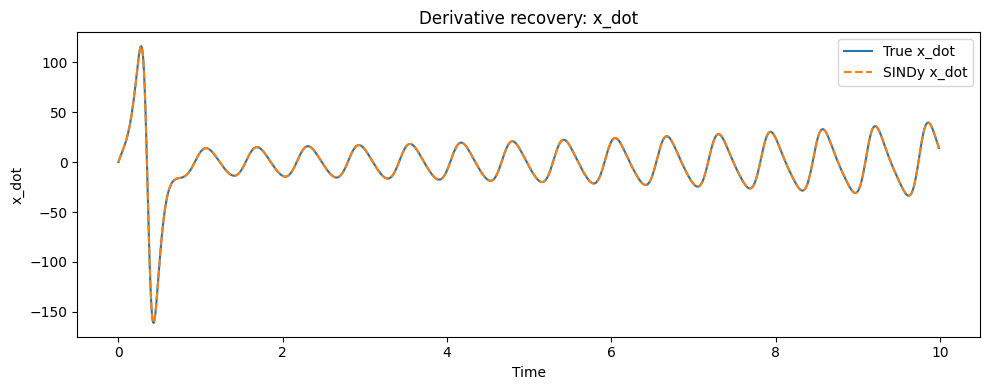

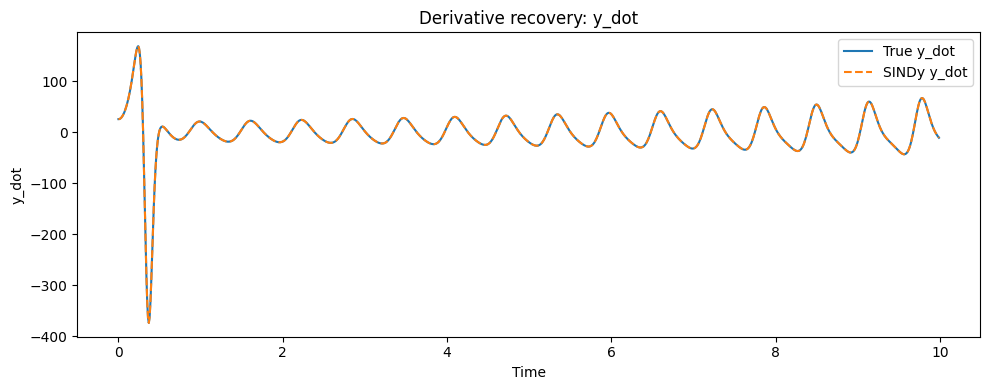

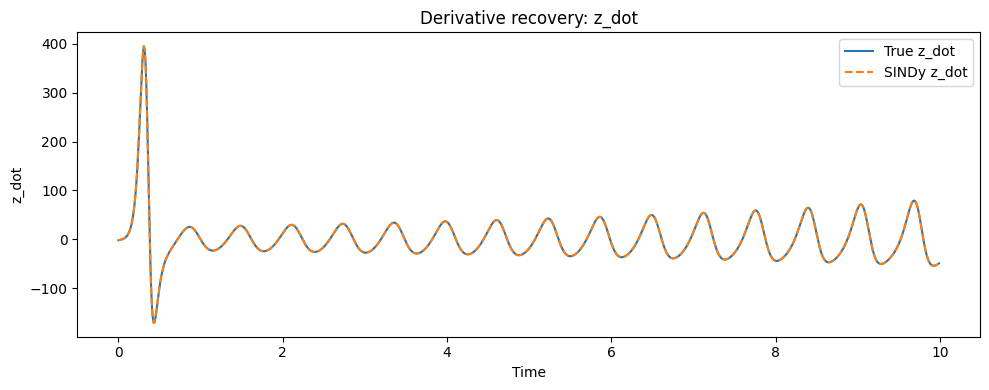

In [11]:
n_plot = 1000

for component_idx, component_name in enumerate(target_names):
    plt.figure(figsize=(10, 4))

    plt.plot(
        time_grid[:n_plot],
        true_derivatives[:n_plot, component_idx],
        label=f"True {component_name}",
    )
    plt.plot(
        time_grid[:n_plot],
        predicted_derivatives[:n_plot, component_idx],
        linestyle="--",
        label=f"SINDy {component_name}",
    )

    plt.xlabel("Time")
    plt.ylabel(component_name)
    plt.title(f"Derivative recovery: {component_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


The curves should lie almost exactly on top of each other because the correct equations have been recovered.


## 9. Why accurate equations do not imply identical long-run trajectories

The Lorenz system is chaotic. Small errors in coefficients, initial conditions, or numerical integration can grow rapidly over time.

Therefore:

- derivative accuracy measures whether the local vector field is correct,
- long-run trajectory agreement is not a reliable criterion for a chaotic system.

Two trajectories may diverge pointwise while still following the same attractor and being generated by nearly identical equations.


## 10. A small threshold sensitivity check

The threshold controls which coefficients survive STLSQ.

We compare a few representative values rather than performing a large hyperparameter sweep:

- a very small threshold,
- the default threshold used above,
- a threshold close to the smallest true coefficient magnitude,
- a threshold large enough to remove true terms.


In [13]:
thresholds = [1e-6, 0.05, 0.5, 1.1]

threshold_rows = []

for threshold in thresholds:
    threshold_coefficients = stlsq(
        theta_matrix,
        true_derivatives,
        threshold=threshold,
        max_iter=20,
    )

    threshold_predictions = (
        theta_matrix @ threshold_coefficients
    )

    threshold_rows.append({
        "threshold": threshold,
        "active_coefficients": int(
            np.count_nonzero(threshold_coefficients)
        ),
        "derivative_mse": np.mean(
            (
                true_derivatives
                - threshold_predictions
            ) ** 2
        ),
        "maximum_coefficient_error": np.max(
            np.abs(
                threshold_coefficients
                - expected_coefficients
            )
        ),
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results


,threshold,active_coefficients,derivative_mse,maximum_coefficient_error
0,0.000001,7,4.605102e-27,1.776357e-14
1,0.050000,7,4.605102e-27,1.776357e-14
2,0.500000,7,4.605102e-27,1.776357e-14
3,1.100000,3,2.670171e+03,3.017523e+01



The correct seven terms remain stable over a broad range of thresholds. Once the threshold reaches the magnitude of genuine coefficients, true terms can be deleted and the error rises sharply.

This illustrates why the threshold should be interpreted relative to the scale of the coefficients.


## 11. Main takeaways

1. **The Lorenz equations are sparse in a quadratic library.**  
   Only seven of the thirty possible coefficients are active.

2. **SINDy recovers both the correct terms and their coefficients.**  
   Under clean conditions, the recovery error is close to numerical precision.

3. **The candidate library must contain the true dynamics.**  
   The $xy$ and $xz$ interaction terms are essential.

4. **Exact derivative information makes the problem much easier.**  
   Real applications often require noisy derivative estimation, which can substantially degrade recovery.

5. **Chaos does not prevent equation discovery.**  
   SINDy estimates the local vector field, not one permanently synchronized long-run trajectory.

6. **The threshold must respect coefficient scale.**  
   A threshold that is too high removes genuine terms.

7. **This is a positive control for the finance experiments.**  
   SINDy works extremely well when the system is closed, sparse, stationary, and correctly represented by the library. Treasury yields violate several of these assumptions.
